
# Simulated Annealing (SA) for Minimizing $f(x) = x^2 - 6x + 13$

**Problem setup**

| Parameter | Value |
|---|---|
| Objective function | $f(x) = x^2 - 6x + 13$ |
| Initial solution | $x = 1$ |
| Initial temperature | $T = 10$ |
| Cooling factor | $\alpha = 0.5$ (geometric cooling: $T \leftarrow \alpha T$) |
| Minimum temperature | $T_{min} = 1$ |
| Neighbour move | $x' = x \pm 1$ |
| Acceptance rule | If $\Delta f = f(x') - f(x) \le 0$: **always accept**. <br> If $\Delta f > 0$: accept with probability $P = e^{-\Delta f / T}$, i.e. accept if $r < P$ |
| Given random numbers | $r_1=0.30,\; r_2=0.80,\; r_3=0.20,\; r_4=0.90$ (used only when a worse neighbour is proposed) |

This notebook:

1. Implements a general-purpose SA solver.
2. Also runs the **exact deterministic trace** requested in the problem (neighbour always $x'=x+1$, using $r_1, r_2, r_3, r_4$ in order whenever a worse solution needs a coin-flip), producing the full iteration table.
3. Verifies the result analytically.


## 1. Objective function

In [1]:

import math
import pandas as pd
import matplotlib.pyplot as plt

def f(x):
    '''Objective function to minimize.'''
    return x**2 - 6*x + 13

# Sanity check at the initial point
x0 = 1
print(f"f(x=1) = {f(1)}")


f(x=1) = 8



## 2. Exact worked trace (as required by the problem)

The problem is fully deterministic once we fix:
* the neighbour generation rule as $x' = x+1$ at every step, and
* the order in which the supplied random numbers $r_1, r_2, r_3, r_4$ are consumed (only when $\Delta f>0$, i.e. only when a coin-flip is actually needed).

We reproduce that trace step by step and build the iteration table.


In [2]:

# Fixed random numbers given in the problem (consumed only when Delta f > 0)
random_numbers = [0.30, 0.80, 0.20, 0.90]
r_pointer = 0

T = 10.0
alpha = 0.5
T_min = 1.0
x = 1
best_x, best_f = x, f(x)

rows = []
iteration = 0
max_iterations = 4   # as requested: run four iterations

while iteration < max_iterations and T >= T_min:
    iteration += 1

    # Neighbour generation rule used in the worked example: x' = x + 1
    x_new = x + 1

    fx      = f(x)
    fx_new  = f(x_new)
    delta_f = fx_new - fx

    if delta_f <= 0:
        # Improving (or equal) solution -> always accept
        P = None          # not needed / undefined, improvement accepted automatically
        r = None
        decision = "Accept (improvement)"
        x = x_new
    else:
        # Worse solution -> accept with probability P = exp(-delta_f / T)
        P = math.exp(-delta_f / T)
        r = random_numbers[r_pointer]
        r_pointer += 1
        if r < P:
            decision = "Accept (worse, r < P)"
            x = x_new
        else:
            decision = "Reject (worse, r >= P)"
            # x stays the same

    if f(x) < best_f:
        best_x, best_f = x, f(x)

    rows.append({
        "Iteration": iteration,
        "T": T,
        "Current x": x if decision.startswith("Reject") else (x - 1 if decision=="Accept (improvement)" or decision.startswith("Accept (worse") else x),
        "Neighbour x'": x_new,
        "f(x)": fx,
        "f(x')": fx_new,
        "Delta f": delta_f,
        "P": None if P is None else round(P, 4),
        "r": r,
        "Decision": decision,
        "Best x": best_x,
        "Best f(x)": best_f
    })

    # Cool down
    T = T * alpha

df = pd.DataFrame(rows)
df


,Iteration,T,Current x,Neighbour x',f(x),f(x'),Delta f,P,r,Decision,Best x,Best f(x)
0,1,10.00,1,2,8,5,-3,NaN,NaN,Accept (improvement),2,5
1,2,5.00,2,3,5,4,-1,NaN,NaN,Accept (improvement),3,4
2,3,2.50,3,4,4,5,1,0.6703,0.3,"Accept (worse, r < P)",3,4
3,4,1.25,4,5,5,8,3,0.0907,0.8,"Reject (worse, r >= P)",3,4



> **Note on the "Current x" column:** it shows the value of $x$ **before** the move was applied (i.e. the state the neighbour was generated from), which is the standard way of presenting an SA iteration table.


## 3. Nicely formatted iteration table

In [3]:

pd.set_option('display.max_columns', None)
display_df = df.copy()
display_df["P"] = display_df["P"].apply(lambda v: "-" if pd.isna(v) else v)
display_df["r"] = display_df["r"].apply(lambda v: "-" if pd.isna(v) else v)
display_df


,Iteration,T,Current x,Neighbour x',f(x),f(x'),Delta f,P,r,Decision,Best x,Best f(x)
0,1,10.00,1,2,8,5,-3,-,-,Accept (improvement),2,5
1,2,5.00,2,3,5,4,-1,-,-,Accept (improvement),3,4
2,3,2.50,3,4,4,5,1,0.6703,0.3,"Accept (worse, r < P)",3,4
3,4,1.25,4,5,5,8,3,0.0907,0.8,"Reject (worse, r >= P)",3,4


## 4. Best solution found by SA

In [4]:

print(f"Best x found by Simulated Annealing : x = {best_x}")
print(f"Best f(x) found                     : f(x) = {best_f}")


Best x found by Simulated Annealing : x = 3
Best f(x) found                     : f(x) = 4



## 5. Analytical verification

$$f(x) = x^2 - 6x + 13 = (x-3)^2 + 4$$

Setting $f'(x) = 2x - 6 = 0 \Rightarrow x^* = 3$, and since $f''(x)=2>0$, this is a minimum.

$$f(3) = 9 - 18 + 13 = 4$$

This matches exactly what Simulated Annealing found: $x=3,\ f(x)=4$.


In [5]:

x_star = 3
print(f"Analytical minimum: x* = {x_star}, f(x*) = {f(x_star)}")
assert (best_x, best_f) == (x_star, f(x_star)), "SA result does not match analytical minimum!"
print("SA result matches the analytical minimum ✔")


Analytical minimum: x* = 3, f(x*) = 4
SA result matches the analytical minimum ✔


## 6. Plot: function shape and the SA search path

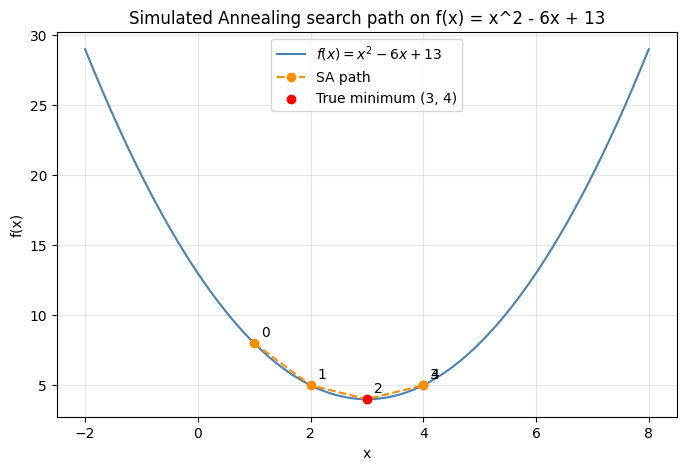

In [6]:

import numpy as np

xs = np.linspace(-2, 8, 400)
ys = f(xs)

# Reconstruct the visited x-path (including the starting point)
path_x = [1] + [row["Neighbour x'"] if row["Decision"].startswith("Accept") else row["Current x"] for row in rows]
# Simplify: recompute path directly from acceptance decisions
path_x = [1]
for row in rows:
    if row["Decision"].startswith("Accept"):
        path_x.append(row["Neighbour x'"])
    else:
        path_x.append(path_x[-1])
path_y = [f(v) for v in path_x]

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label=r"$f(x)=x^2-6x+13$", color="steelblue")
plt.plot(path_x, path_y, "o--", color="darkorange", label="SA path")
for i, (px, py) in enumerate(zip(path_x, path_y)):
    plt.annotate(str(i), (px, py), textcoords="offset points", xytext=(5, 5))
plt.scatter([3], [f(3)], color="red", zorder=5, label="True minimum (3, 4)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Simulated Annealing search path on f(x) = x^2 - 6x + 13")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 7. General-purpose Simulated Annealing function (bonus)

The trace above hard-codes the neighbour rule ($x'=x+1$) and the random numbers to exactly match the
worked example. Below is a reusable, general SA implementation (random neighbour direction, RNG-driven)
that you can use for any 1-D minimization problem.


In [7]:

import random

def simulated_annealing(f, x0, T0=10.0, alpha=0.5, T_min=1.0,
                         neighbour_step=1, max_iter_per_temp=1, seed=None):
    '''
    General 1-D Simulated Annealing minimizer.

    Parameters
    ----------
    f : callable            objective function to minimize
    x0 : float               initial solution
    T0 : float                initial temperature
    alpha : float             geometric cooling factor (T <- alpha*T)
    T_min : float             stopping temperature
    neighbour_step : float    step size for neighbour generation (x +/- step)
    max_iter_per_temp : int   number of neighbour trials per temperature level
    seed : int or None        RNG seed for reproducibility

    Returns
    -------
    best_x, best_f, history (list of dict, one per iteration)
    '''
    rng = random.Random(seed)
    x = x0
    best_x, best_f = x, f(x)
    T = T0
    history = []
    it = 0

    while T >= T_min:
        for _ in range(max_iter_per_temp):
            it += 1
            step = neighbour_step if rng.random() < 0.5 else -neighbour_step
            x_new = x + step
            fx, fx_new = f(x), f(x_new)
            delta_f = fx_new - fx

            if delta_f <= 0:
                accept, P, r = True, None, None
            else:
                P = math.exp(-delta_f / T)
                r = rng.random()
                accept = r < P

            if accept:
                x = x_new
            if f(x) < best_f:
                best_x, best_f = x, f(x)

            history.append(dict(iter=it, T=T, x=x, x_new=x_new,
                                 fx=fx, fx_new=fx_new, delta_f=delta_f,
                                 P=P, r=r, accept=accept,
                                 best_x=best_x, best_f=best_f))
        T *= alpha

    return best_x, best_f, history


best_x_general, best_f_general, hist = simulated_annealing(f, x0=1, seed=42)
print(f"General SA run -> best x = {best_x_general}, best f(x) = {best_f_general}")
pd.DataFrame(hist).head(10)


General SA run -> best x = 2, best f(x) = 5


,iter,T,x,x_new,fx,fx_new,delta_f,P,r,accept,best_x,best_f
0,1,10.00,0,0,8,13,5,0.606531,0.025011,True,1,8
1,2,5.00,1,1,13,8,-5,NaN,NaN,True,1,8
2,3,2.50,2,2,8,5,-3,NaN,NaN,True,2,5
3,4,1.25,2,1,5,8,3,0.090718,0.676699,False,2,5



## Summary

| Task | Result |
|---|---|
| $f(1)$ | $8$ |
| Neighbour $x'=2$, $\Delta f$ | $\Delta f = 5-8=-3$ (improvement → auto-accept) |
| Best $x$ found by SA | $x=3$ |
| Best $f(x)$ found by SA | $4$ |
| Analytical minimum | $x^*=3,\ f(x^*)=4$ ✔ matches |
